In [1]:
import pandas as pd
import numpy as np
beta=1 #STIFFNESS
# Loading and trasforming into a numpy matrix the dataset
df=pd.read_csv('Iris.csv')
selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()
print(f"shape: {data_matrix.shape}")

shape: (150, 4)


In [2]:
#Finding the range of the dataset
max_values=df[selected_columns].max()
min_values=df[selected_columns].min()

# Generate initial centroids randomly within the range of the dataset
initial_centroids=np.random.uniform(min_values, max_values, (3,4))
print("Initial centroids:")
print(initial_centroids)

Initial centroids:
[[5.53227329 2.92024008 3.65816037 2.2732622 ]
 [4.86101516 2.73176013 3.39788779 0.37587208]
 [4.49806428 3.32309178 1.58798479 0.84550601]]


In [3]:
# Euclidean distance function
def d(a,b):
    return np.sqrt(np.sum((a-b)**2))

In [4]:
# First assignment
responsibilities=np.zeros((data_matrix.shape[0],3))
for i in range(data_matrix.shape[0]):
    distances = np.array([d(data_matrix[i], centroid) for centroid in initial_centroids])
    responsibilities[i]=np.exp(-beta*distances)/np.sum(np.exp(-beta*distances))
#print("Initial responsibilities:")
#print(responsibilities)


In [5]:
for k in range(10):
    # Calculating the new centroids
    for j in range(3):
        r_j = responsibilities[:, j] # prendo le colonne della matrice responsibilities
        initial_centroids[j] = np.sum(r_j[:, np.newaxis] * data_matrix, axis=0) / np.sum(r_j)

    # Updating the responsibilities with the new centroids
    for i in range(data_matrix.shape[0]):
        distances = np.array([d(data_matrix[i], centroid) for centroid in initial_centroids])
        responsibilities[i]=np.exp(-beta*distances)/np.sum(np.exp(-beta*distances))

print(np.sum(responsibilities[:, 0]))
print(np.sum(responsibilities[:, 1]))
print(np.sum(responsibilities[:, 2]))


48.955711875596364
48.82914640268109
52.215141721722546


In [6]:
cluster_assignments = np.argmax(responsibilities, axis=1)
print(cluster_assignments)
counts = np.bincount(cluster_assignments)
print(counts)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 1 0 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 2 1 1 1 1 2 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0]
[50 47 53]


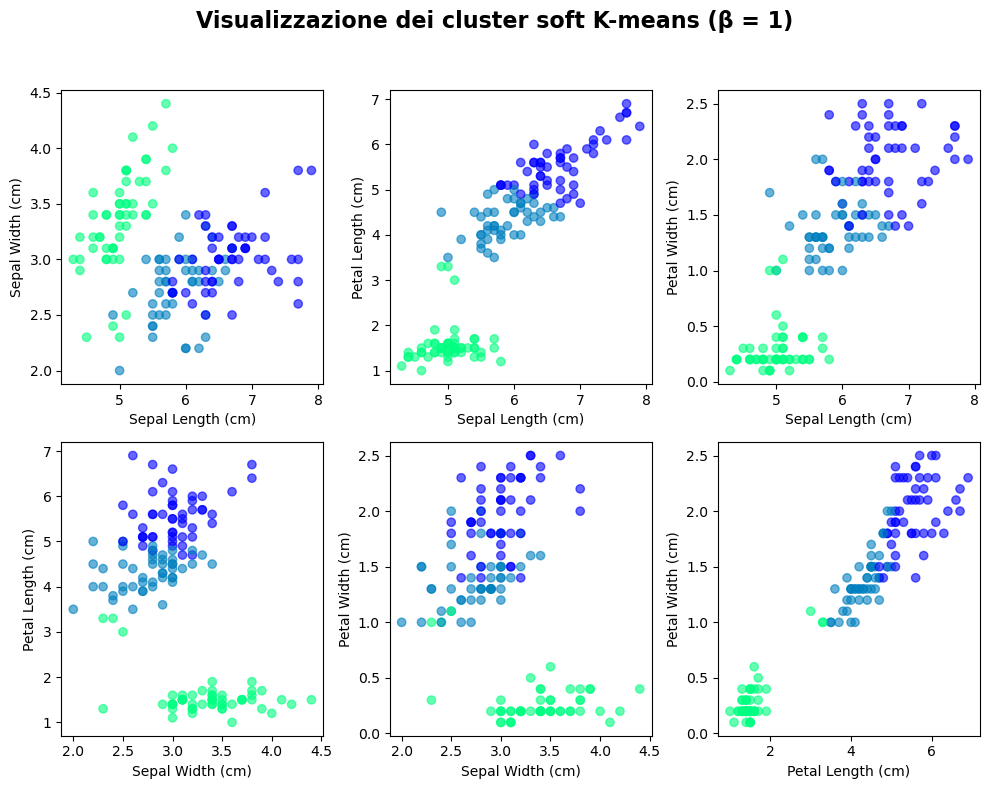

In [7]:
import matplotlib.pyplot as plt

soft_assignments = np.argmax(responsibilities, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(10, 8))

axes[0, 0].scatter(data_matrix[:,0], data_matrix[:,1], c=soft_assignments, cmap='winter', alpha=0.6)
axes[0, 0].set_xlabel("Sepal Length (cm)")
axes[0, 0].set_ylabel("Sepal Width (cm)")

axes[0, 1].scatter(data_matrix[:,0], data_matrix[:,2], c=soft_assignments, cmap='winter', alpha=0.6)
axes[0, 1].set_xlabel("Sepal Length (cm)")
axes[0, 1].set_ylabel("Petal Length (cm)")

axes[0, 2].scatter(data_matrix[:,0], data_matrix[:,3], c=soft_assignments, cmap='winter', alpha=0.6)
axes[0, 2].set_xlabel("Sepal Length (cm)")
axes[0, 2].set_ylabel("Petal Width (cm)")

axes[1, 0].scatter(data_matrix[:,1], data_matrix[:,2], c=soft_assignments, cmap='winter', alpha=0.6)
axes[1, 0].set_xlabel("Sepal Width (cm)")
axes[1, 0].set_ylabel("Petal Length (cm)")

axes[1, 1].scatter(data_matrix[:,1], data_matrix[:,3], c=soft_assignments, cmap='winter', alpha=0.6)
axes[1, 1].set_xlabel("Sepal Width (cm)")
axes[1, 1].set_ylabel("Petal Width (cm)")

axes[1, 2].scatter(data_matrix[:,2], data_matrix[:,3], c=soft_assignments, cmap='winter', alpha=0.6)
axes[1, 2].set_xlabel("Petal Length (cm)")
axes[1, 2].set_ylabel("Petal Width (cm)")

fig.suptitle("Visualizzazione dei cluster soft K-means (β = 1)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig("soft_k_means_cluster_grid.pdf", format="pdf")

<h3>Purity score:</h3>

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix

def purity_score(y_true, y_pred):
    """
    Calcola la purity tra etichette vere (y_true) e assegnazioni di clustering (y_pred).
    
    Parameters:
    - y_true: array-like, etichette reali
    - y_pred: array-like, etichette di clustering
    
    Returns:
    - purity: float, valore tra 0 e 1
    """
    # Matrice di contingenza: righe = classi vere, colonne = cluster
    contingency_matrix = confusion_matrix(y_true, y_pred)
    
    # Somma dei massimi per ogni colonna (cluster)
    max_per_cluster = np.max(contingency_matrix, axis=0)
    
    # Purezza = somma dei massimi / totale dei campioni
    purity = np.sum(max_per_cluster) / np.sum(contingency_matrix)
    
    return purity

print("Clustering")
print(soft_assignments)

# Let's take the ground truth from the database
ground_truth = np.array([0]*50 + [1]*50 + [2]*50)
print(ground_truth)
print("Purity score of k-means:",purity_score(ground_truth,soft_assignments))
print(confusion_matrix(ground_truth,soft_assignments))

Clustering
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 1 0 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 2 1 1 1 1 2 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Purity score of k-means: 0.9
[[ 0  0 50]
 [ 6 41  3]
 [44  6  0]]


In [9]:
step = 1
it = np.arange(1, 16)
purity = np.zeros(15)

for t in range (15):
# First assignment
    responsibilities=np.zeros((data_matrix.shape[0],3))
    for i in range(data_matrix.shape[0]):
        distances = np.array([d(data_matrix[i], centroid) for centroid in initial_centroids])
        responsibilities[i]=np.exp(-beta*distances)/np.sum(np.exp(-beta*distances))
    #print("Initial responsibilities:")
    #print(responsibilities)
    for k in range(step):
        # Calculating the new centroids
        for j in range(3):
            r_j = responsibilities[:, j] # prendo le colonne della matrice responsibilities
            initial_centroids[j] = np.sum(r_j[:, np.newaxis] * data_matrix, axis=0) / np.sum(r_j)
    
        # Updating the responsibilities with the new centroids
        for i in range(data_matrix.shape[0]):
            distances = np.array([d(data_matrix[i], centroid) for centroid in initial_centroids])
            responsibilities[i]=np.exp(-beta*distances)/np.sum(np.exp(-beta*distances))
    soft_assignments = np.argmax(responsibilities, axis=1)
    purity[t] = purity_score(ground_truth, soft_assignments)
    step+=1

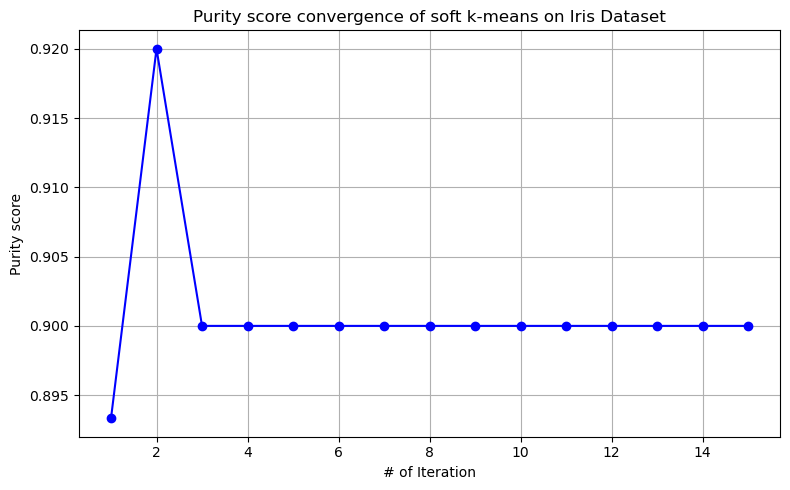

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(it, purity, marker='o', linestyle='-', color='blue')
plt.title("Purity score convergence of soft k-means on Iris Dataset")
plt.xlabel("# of Iteration")
plt.ylabel("Purity score")
plt.grid(True)
plt.tight_layout()
plt.savefig("purity_vs_iteration.pdf", format="pdf")
plt.show()

In [17]:
def infomax(labels):
    M = len(labels)
    unique, counts = np.unique(labels, return_counts=True)
    probs = counts / M
    H = -np.sum(probs * np.log(probs))
    return H
from sklearn.metrics import davies_bouldin_score

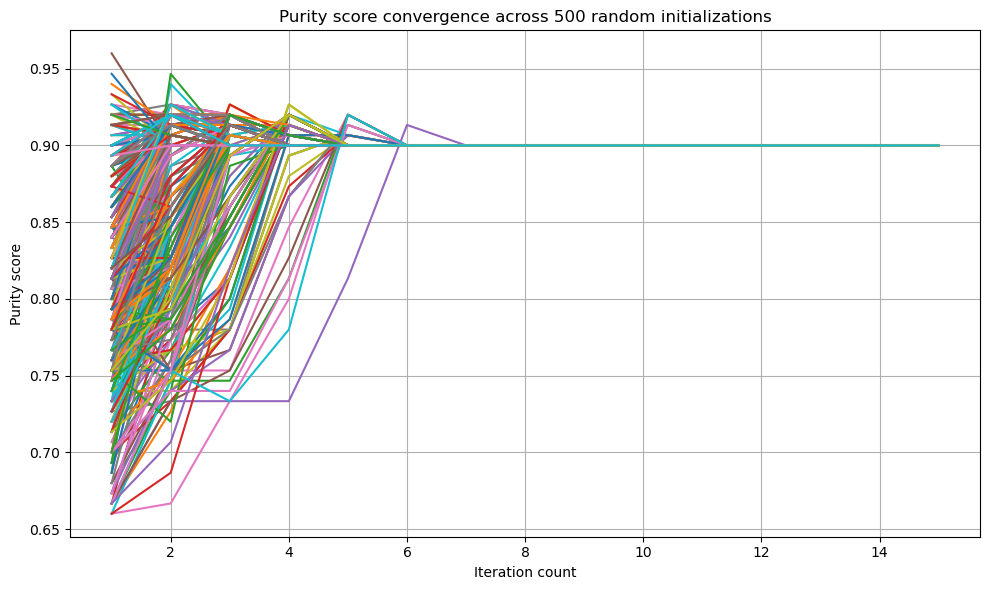

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# Parametri
n_runs = 500
n_iterations = 15
it = np.arange(1, n_iterations + 1)

# Lista per salvare tutte le curve di purity
all_purities = []
all_db= []
all_infomax= []
for run in range(n_runs):
    step = 1
    purity = np.zeros(n_iterations)
    db_index=np.zeros (n_iterations)
    infomax_index=np.zeros(n_iterations)

    # Centroidi iniziali casuali per questo run
    initial_centroids = np.random.uniform(min_values, max_values, (3, 4))

    # Inizializza cluster_assignments per ogni run
    soft_assignments = np.zeros(data_matrix.shape[0], dtype=int)

    for t in range(n_iterations):
    # First assignment
        responsibilities=np.zeros((data_matrix.shape[0],3))
        for i in range(data_matrix.shape[0]):
            distances = np.array([d(data_matrix[i], centroid) for centroid in initial_centroids])
            responsibilities[i]=np.exp(-beta*distances)/np.sum(np.exp(-beta*distances))
        #print("Initial responsibilities:")
        #print(responsibilities)
        for k in range(step):
            # Calculating the new centroids
            for j in range(3):
                r_j = responsibilities[:, j] # prendo le colonne della matrice responsibilities
                initial_centroids[j] = np.sum(r_j[:, np.newaxis] * data_matrix, axis=0) / np.sum(r_j)
        
            # Updating the responsibilities with the new centroids
            for i in range(data_matrix.shape[0]):
                distances = np.array([d(data_matrix[i], centroid) for centroid in initial_centroids])
                responsibilities[i]=np.exp(-beta*distances)/np.sum(np.exp(-beta*distances))
        soft_assignments = np.argmax(responsibilities, axis=1)
        # Calculate Purity
        purity[t] = purity_score(ground_truth, soft_assignments)
        #Calculate db_index
        db_index[t]=davies_bouldin_score(data_matrix, soft_assignments)
        # Calculate Infomax_index
        infomax_index[t]=infomax(soft_assignments)
        step+=1

    all_purities.append(purity)
    all_db.append(db_index)
    all_infomax.append(infomax_index)
plt.figure(figsize=(10, 6))
for purity_curve in all_purities:
    plt.plot(it, purity_curve)

plt.title("Purity score convergence across 500 random initializations")
plt.xlabel("Iteration count")
plt.ylabel("Purity score")
plt.grid(True)
plt.tight_layout()
plt.savefig("purity_vs_iteration_random_500.pdf", format="pdf")
plt.show()


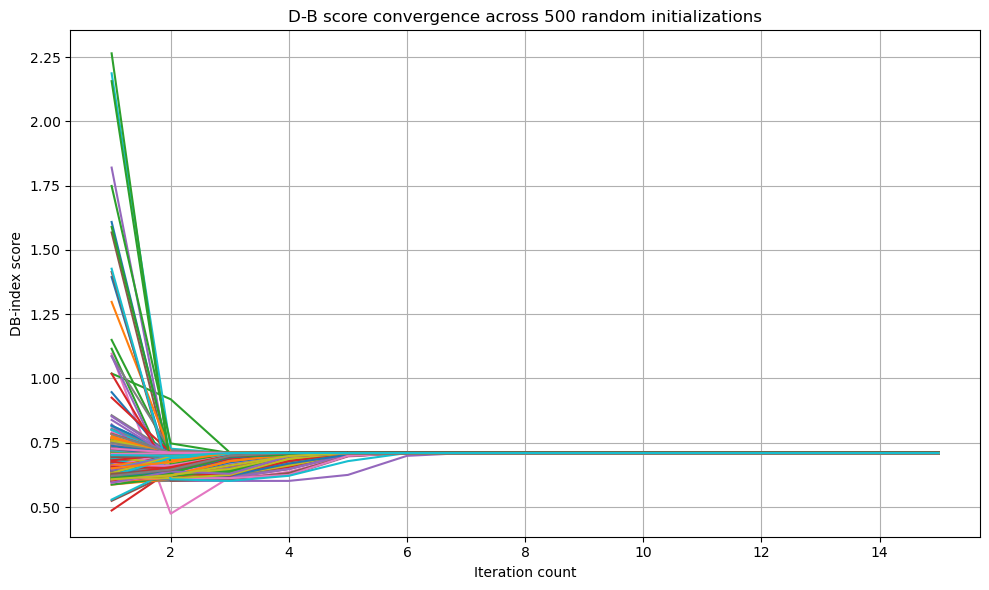

In [13]:
plt.figure(figsize=(10, 6))

for db_curve in all_db:
    plt.plot(it, db_curve)

plt.title("D-B score convergence across 500 random initializations")
plt.xlabel("Iteration count")
plt.ylabel("DB-index score")
plt.grid(True)
plt.tight_layout()
plt.savefig("db_vs_iteration_random_500.pdf", format="pdf")
plt.show()

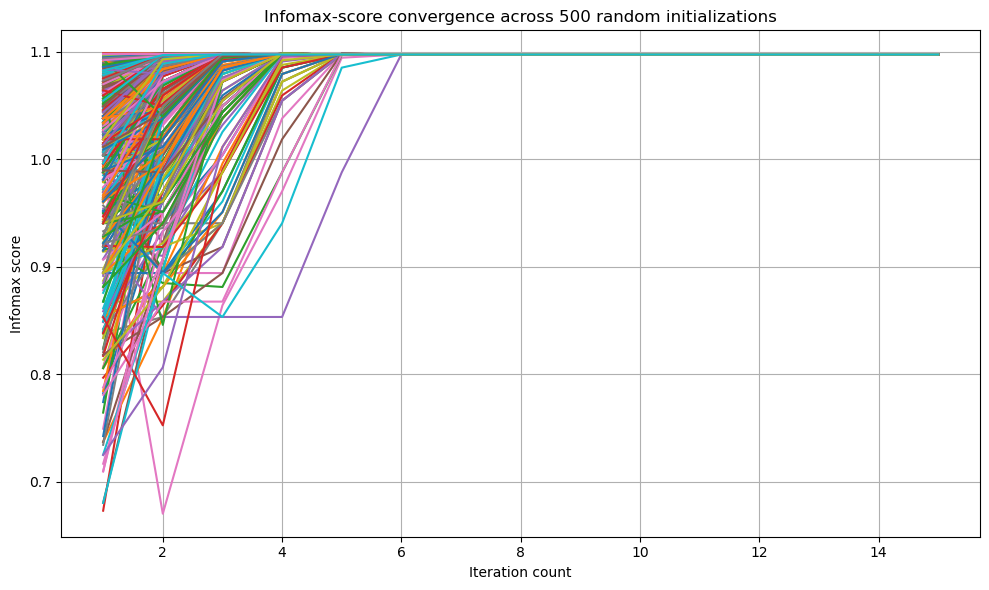

In [14]:
plt.figure(figsize=(10, 6))

for infomax_curve in all_infomax:
    plt.plot(it, infomax_curve)

plt.title("Infomax-score convergence across 500 random initializations")
plt.xlabel("Iteration count")
plt.ylabel("Infomax score")
plt.grid(True)
plt.tight_layout()
plt.savefig("infomax_vs_iteration_random_500.pdf", format="pdf")
plt.show()